In [2]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import keras
from keras import layers
import numpy as np
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from keras import models
from IPython import display
import scipy.io.wavfile

import pandas as pd
from scipy.signal import resample

keras.utils.set_random_seed(41)

I0000 00:00:1776440584.300251  311124 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776440586.849560  311124 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
BASE_DATA_DIR = "./datasets/"
BATCH_SIZE = 16
NUM_CLASSES = 8
EPOCHS = 500
SAMPLE_RATE = 48000

In [4]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory='datasets',
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    seed=41,
    output_sequence_length=None,
    label_mode = 'int',
    subset='both')

label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)


Found 4240 files belonging to 8 classes.
Using 3392 files for training.
Using 848 files for validation.

label names: ['angry' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprised']


In [5]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)


In [6]:
def plot_single_spectrogram(sample_wav_data):
    spectrogram = layers.STFTSpectrogram(
        mode="log",
        frame_length=SAMPLE_RATE * 20 // 1000,
        frame_step=SAMPLE_RATE * 5 // 1000,
        fft_length=1024,
        trainable=False,
    # )(sample_wav_data[None, ...])[0, ...]
    )(sample_wav_data)[0,...]

    # Plot the spectrogram
    plt.imshow(spectrogram, origin="lower")
    plt.title("Single Channel Spectrogram")
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

(16, 57658, 1)


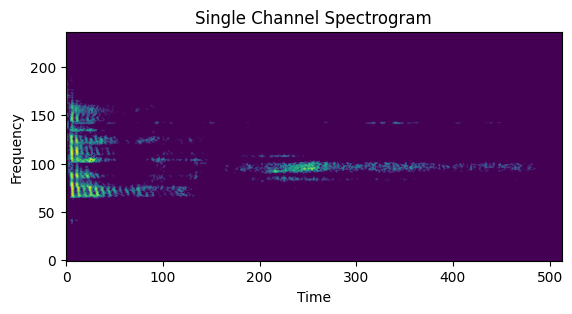

In [7]:
for t in train_ds.take(1):
    print(t[0].shape)
    plot_single_spectrogram(t[0])

In [8]:
stftlayer = layers.STFTSpectrogram(
            mode="log",
            frame_length=SAMPLE_RATE * 40 // 1000,
            frame_step=SAMPLE_RATE * 15 // 1000,
            trainable=False,
        )

In [8]:
keras.backend.clear_session(free_memory=True)
model1d = keras.Sequential(
    [
        layers.InputLayer((None,1)),
        stftlayer,
        layers.Conv1D(64, 8, activation="relu"),
        layers.Conv1D(128, 16, activation="relu"),
        layers.LayerNormalization(),
        # layers.MaxPooling1D(4),
        layers.Conv1D(128, 8, activation="relu"),
        layers.Conv1D(256, 16, padding='same', activation="relu"),
        layers.Conv1D(512, 64, padding='same', activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=0.05)),
        layers.LayerNormalization(),
        layers.MaxPooling1D(4),        
        # layers.LayerNormalization(),
        layers.Dropout(0.5),
        layers.GlobalMaxPooling1D(),
        layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=0.05)),
        layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=0.05)),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="model_1d_non_trainble_stft",
)
model1d.compile(
    optimizer=keras.optimizers.AdamW(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model1d.summary()

Model: "model_1d_non_trainble_stft"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ stft_spectrogram_1              │ (None, None, 1025)     │     3,936,000 │
│ (STFTSpectrogram)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 64)       │       524,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, None, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, None, 128)      │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, None, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, None, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, None, 512)      │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, None, 512)      │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,905,224 (53.04 MB)

 Trainable params: 9,969,224 (38.03 MB)

 Non-trainable params: 3,936,000 (15.01 MB)

In [9]:
history_model1d = model1d.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )
    ],
)

Epoch 1/200
212/212 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.1424 - loss: 2497.6350 - val_accuracy: 0.1394 - val_loss: 2114.0127
Epoch 2/200
212/212 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - accuracy: 0.1816 - loss: 1783.0358 - val_accuracy: 0.2260 - val_loss: 1474.5768
Epoch 3/200
212/212 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.2361 - loss: 1221.1478 - val_accuracy: 0.3341 - val_loss: 991.9385
Epoch 4/200
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3340 - loss: 818.0663 - val_accuracy: 0.2981 - val_loss: 669.3967
Epoch 5/200
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4239 - loss: 574.3026 - val_accuracy: 0.6034 - val_loss: 504.5139
Epoch 6/200
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4794 - loss: 476.3086 - val_accuracy: 0.5889 - val_loss: 454.8451
Epoch 7/200
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5380 - loss: 438.0411 - val_accuracy: 0.6130 - val_loss: 422.5459
Epoch 8/200
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - a

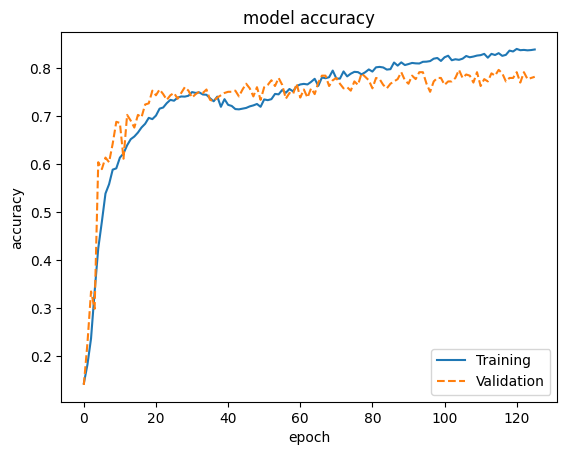

In [10]:
plt.plot(history_model1d.history['accuracy'])
plt.plot(history_model1d.history['val_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

In [9]:
keras.backend.clear_session(free_memory=True)
model1d = keras.Sequential(
    [
        layers.InputLayer((None,1)),
        stftlayer,
        layers.Conv1D(64, 8, activation="relu"),
        layers.Conv1D(128, 16, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=0.05)),
        layers.LayerNormalization(),
        # layers.MaxPooling1D(4),
        layers.Conv1D(128, 8, activation="relu"),
        layers.Conv1D(256, 16, padding='same', activation="relu"),
        layers.Conv1D(512, 64, padding='same', activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=0.05)),
        layers.LayerNormalization(),
        layers.MaxPooling1D(4),        
        # layers.LayerNormalization(),
        layers.Dropout(0.5),
        layers.GlobalMaxPooling1D(),
        layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=0.05)),
        layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=0.05)),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="model_1d_non_trainble_stft",
)
model1d.compile(
    optimizer=keras.optimizers.AdamW(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model1d.summary()

Model: "model_1d_non_trainble_stft"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ stft_spectrogram_1              │ (None, None, 1025)     │     3,936,000 │
│ (STFTSpectrogram)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 64)       │       524,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, None, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, None, 128)      │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, None, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, None, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, None, 512)      │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, None, 512)      │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,905,224 (53.04 MB)

 Trainable params: 9,969,224 (38.03 MB)

 Non-trainable params: 3,936,000 (15.01 MB)

In [10]:
history_model1d = model1d.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EPOCHS/10,
            restore_best_weights=True,
        )
    ],
)

Epoch 1/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.1371 - loss: 2636.1199 - val_accuracy: 0.1418 - val_loss: 2245.8381
Epoch 2/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - accuracy: 0.1633 - loss: 1908.5441 - val_accuracy: 0.1971 - val_loss: 1593.8247
Epoch 3/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.1857 - loss: 1334.1627 - val_accuracy: 0.1490 - val_loss: 1098.6489
Epoch 4/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2400 - loss: 918.5781 - val_accuracy: 0.2260 - val_loss: 763.7247
Epoch 5/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.3520 - loss: 663.3209 - val_accuracy: 0.5625 - val_loss: 588.7289
Epoch 6/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4390 - loss: 556.6882 - val_accuracy: 0.5385 - val_loss: 531.1944
Epoch 7/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5056 - loss: 510.2785 - val_accuracy: 0.5889 - val_loss: 490.6386
Epoch 8/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - 

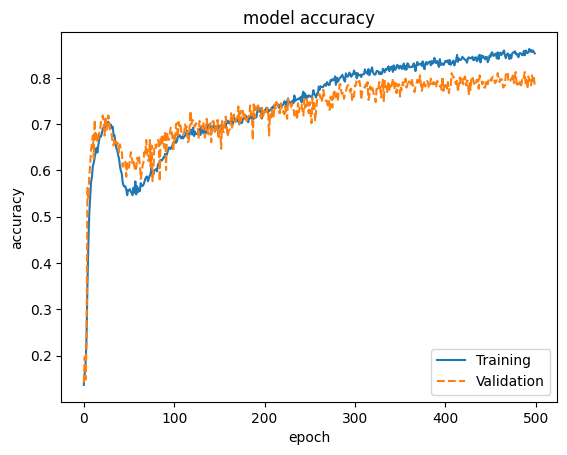

In [11]:
plt.plot(history_model1d.history['accuracy'])
plt.plot(history_model1d.history['val_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

In [12]:
model1d.evaluate(test_ds)

27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 307ms/step - accuracy: 0.8079 - loss: 1.5362


[1.5362279415130615, 0.8078703880310059]